# Product User Churn Prediction & Analytics

## Churn Prediction & Model Evaluation

This notebook evaluates machine-learning models developed to predict user churn for a fictional subscription-based productivity application.

### Objectives

- Prepare the churn dataset for machine learning
- Compare Logistic Regression and Random Forest models
- Evaluate model performance using ROC-AUC and PR-AUC
- Examine precision and recall for the churn class
- Analyze prediction thresholds
- Interpret important model features
- Translate model outputs into product analytics insights

The models use user behavior from the feature window (January-April 2026) to predict churn outcomes observed during the outcome window (May-June 2026).

Because churn is an imbalanced target, **PR-AUC, precision, and recall** are emphasized alongside ROC-AUC rather than relying on accuracy alone.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

# Load the churn dataset
df = pd.read_csv("../data/processed/ml_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3307, 19)


,user_id,total_events,total_sessions,active_days,login_count,product_view_count,search_count,add_to_cart_count,purchase_count,subscription_count,days_since_last_activity,days_since_last_login,days_since_last_product_view,events_per_active_day,sessions_per_active_day,search_rate,cart_rate,purchase_rate,churn
0,U00001,14,6,5,5,5,2,1,0,0,87,87,87,2.80,1.20,0.1429,0.0714,0.0000,0
1,U00002,4,2,1,1,1,1,0,0,0,9,9,9,4.00,2.00,0.2500,0.0000,0.0000,0
2,U00003,119,39,38,38,38,24,16,1,1,0,0,0,3.13,1.03,0.2017,0.1345,0.0084,0
3,U00004,15,6,5,5,5,2,2,0,0,43,43,43,3.00,1.20,0.1333,0.1333,0.0000,0
4,U00005,3,2,1,1,1,0,0,0,0,73,73,73,3.00,2.00,0.0000,0.0000,0.0000,0


In [2]:
# Separate features and target

X = df.drop(columns=["user_id", "churn"])
y = df["churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Feature matrix shape: (3307, 17)
Target shape: (3307,)

Target distribution:
churn
0    3217
1      90
Name: count, dtype: int64

Target percentage:
churn
0    97.28
1     2.72
Name: proportion, dtype: float64


In [3]:
# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts())

print("\nTest churn distribution:")
print(y_test.value_counts())

Training set: (2645, 17)
Test set: (662, 17)

Training churn distribution:
churn
0    2573
1      72
Name: count, dtype: int64

Test churn distribution:
churn
0    644
1     18
Name: count, dtype: int64


In [4]:
# Train Logistic Regression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

# Generate predictions
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [5]:
# Evaluate Logistic Regression

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_pr_auc = average_precision_score(
    y_test,
    logistic_probabilities
)

print(f"Logistic Regression ROC-AUC: {logistic_roc_auc:.3f}")
print(f"Logistic Regression PR-AUC:  {logistic_pr_auc:.3f}")

Logistic Regression ROC-AUC: 0.931
Logistic Regression PR-AUC:  0.168


In [6]:
# Classification report and confusion matrix

print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Non-Churned", "Churned"],
        digits=3
    )
)

print("Confusion Matrix")
print(confusion_matrix(y_test, logistic_predictions))

Logistic Regression Classification Report
              precision    recall  f1-score   support

 Non-Churned      1.000     0.815     0.898       644
     Churned      0.131     1.000     0.232        18

    accuracy                          0.820       662
   macro avg      0.566     0.908     0.565       662
weighted avg      0.976     0.820     0.880       662

Confusion Matrix
[[525 119]
 [  0  18]]


In [7]:
# Train Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")

Random Forest training complete.


In [8]:
# Evaluate Random Forest

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_probabilities
)

print(f"Random Forest ROC-AUC: {rf_roc_auc:.3f}")
print(f"Random Forest PR-AUC:  {rf_pr_auc:.3f}")

Random Forest ROC-AUC: 0.953
Random Forest PR-AUC:  0.402


In [9]:
# Random Forest classification report and confusion matrix

print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Non-Churned", "Churned"],
        digits=3
    )
)

print("Confusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Classification Report
              precision    recall  f1-score   support

 Non-Churned      0.996     0.849     0.917       644
     Churned      0.142     0.889     0.244        18

    accuracy                          0.850       662
   macro avg      0.569     0.869     0.581       662
weighted avg      0.973     0.850     0.899       662

Confusion Matrix
[[547  97]
 [  2  16]]


In [10]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ],
    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc
    ],
    "Churn Precision": [
        0.131,
        0.142
    ],
    "Churn Recall": [
        1.000,
        0.889
    ],
    "Churn F1": [
        0.232,
        0.244
    ]
})

model_comparison.round(3)

,Model,ROC-AUC,PR-AUC,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.931,0.168,0.131,1.000,0.232
1,Random Forest,0.953,0.402,0.142,0.889,0.244


In [11]:
# Analyze Random Forest probability thresholds

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]

threshold_results = []

for threshold in thresholds:
    predictions = (rf_probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    threshold_results.append({
        "Threshold": threshold,
        "Users Targeted": int(predictions.sum()),
        "True Churners Identified": int(tp),
        "False Positives": int(fp),
        "Precision": precision,
        "Recall": recall
    })

threshold_analysis = pd.DataFrame(threshold_results)

threshold_analysis.round(3)

,Threshold,Users Targeted,True Churners Identified,False Positives,Precision,Recall
0,0.2,137,17,120,0.124,0.944
1,0.3,129,17,112,0.132,0.944
2,0.4,119,16,103,0.134,0.889
3,0.5,113,16,97,0.142,0.889
4,0.6,99,16,83,0.162,0.889


In [13]:
import matplotlib.pyplot as plt

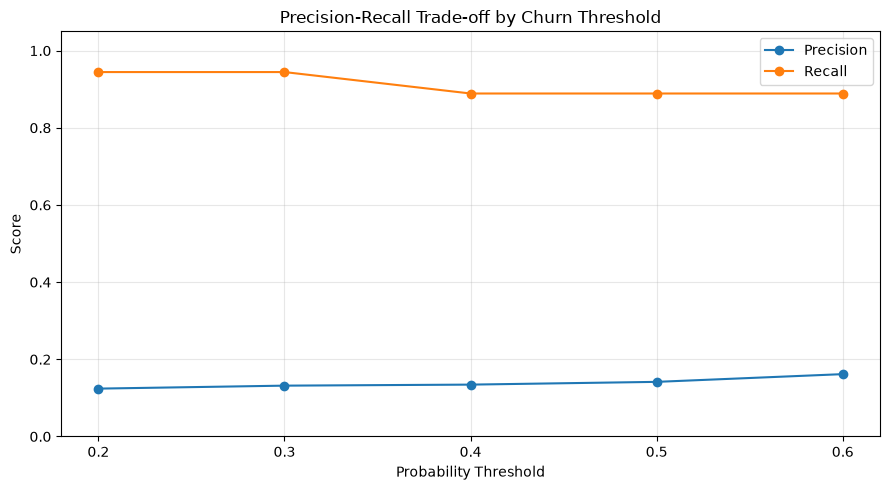

In [14]:
# Visualize the precision-recall trade-off across thresholds

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Recall"],
    marker="o",
    label="Recall"
)

plt.title("Precision-Recall Trade-off by Churn Threshold")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.xticks(threshold_analysis["Threshold"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.round(4))

,Feature,Importance
0,subscription_count,0.3945
1,days_since_last_login,0.1165
2,days_since_last_product_view,0.0989
3,days_since_last_activity,0.0857
4,purchase_rate,0.0814
5,purchase_count,0.0442
6,total_events,0.0305
7,sessions_per_active_day,0.0212
8,product_view_count,0.0184
9,total_sessions,0.0182


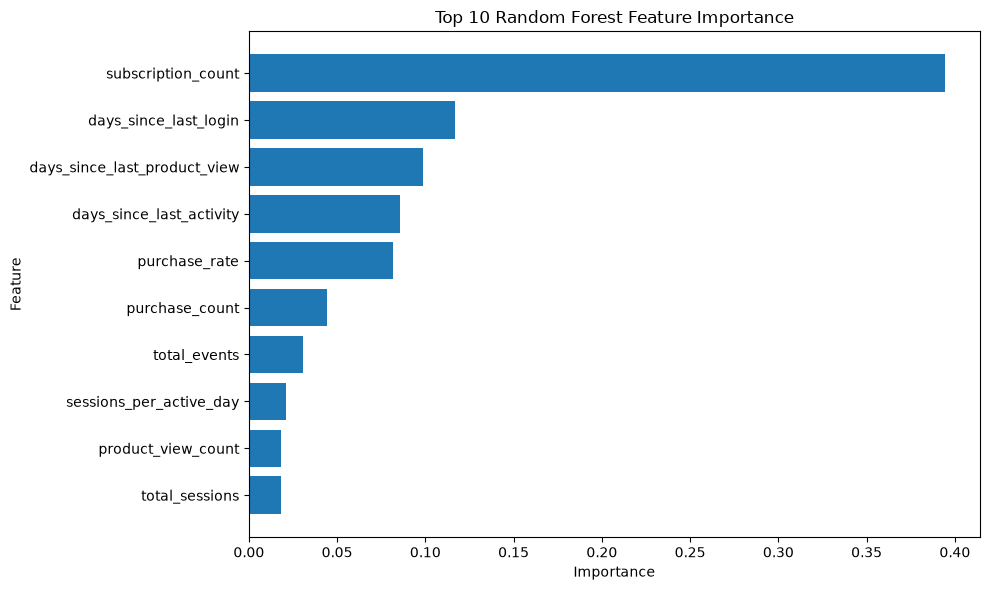

In [16]:
# Visualize top 10 Random Forest features

top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Model Interpretation

The Random Forest model identifies several user-behavior features that contribute to its churn predictions.

### Key observations

- `subscription_count` has the highest feature importance in the model. This should be interpreted cautiously because the synthetic churn definition requires a subscription before a cancellation event can occur. Therefore, this feature reflects part of the dataset construction rather than a causal driver of churn.
- Activity recency features, including `days_since_last_login`, `days_since_last_product_view`, and `days_since_last_activity`, are among the most important predictive signals.
- Purchase behavior, particularly `purchase_rate` and `purchase_count`, also contributes to the model's predictions.
- Overall activity measures such as `total_events` and `total_sessions` contribute to prediction, but have lower Random Forest importance than the leading recency and purchase-related features.

Feature importance describes the contribution of features to the Random Forest's predictive splits. It does not indicate the direction of the relationship and does not establish causality.

Because this project uses synthetic data, these findings should be treated as demonstrations of the modeling workflow rather than evidence of real-world customer behavior.

In [17]:
# Final model evaluation summary

final_model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ],
    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc
    ],
    "Churn Precision": [
        0.131,
        0.142
    ],
    "Churn Recall": [
        1.000,
        0.889
    ],
    "Churn F1": [
        0.232,
        0.244
    ]
})

final_model_summary.round(3)

,Model,ROC-AUC,PR-AUC,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.931,0.168,0.131,1.000,0.232
1,Random Forest,0.953,0.402,0.142,0.889,0.244


## Conclusion

The modeling analysis demonstrates an end-to-end approach to predicting user churn from product behavior.

### Key findings

- The dataset contains **3,307 eligible users**, with a **2.72% churn rate**, making class imbalance an important modeling consideration.
- Logistic Regression achieved a **ROC-AUC of 0.931** and **PR-AUC of 0.168**.
- Random Forest achieved a **ROC-AUC of 0.953** and **PR-AUC of 0.402** on the held-out test set.
- At the default 0.50 probability threshold, Logistic Regression identified all observed churners in the test sample, while Random Forest identified 16 of 18.
- Random Forest feature importance highlights subscription history, activity recency, and purchase-related behavior as important predictive signals in this synthetic dataset.
- Threshold analysis demonstrates that changing the probability threshold changes the number of users targeted and the precision-recall trade-off.

### Product analytics implications

A churn prediction model can be used to prioritize users for potential retention interventions rather than treating every user equally.

The model's probability threshold should be selected based on operational capacity and the relative business costs of false positives and missed churners. The threshold analysis provides a framework for making that decision.

### Limitations

- The dataset is synthetic and does not represent real customer behavior.
- The churn definition and event-generation process introduce structural relationships between some features and the target.
- The test set contains only **18 churned users**, so evaluation metrics may be sensitive to individual observations.
- Feature importance indicates predictive contribution, not causality.
- Further validation on real-world data and future time periods would be required before deployment.

Overall, the project demonstrates the complete workflow from product event data and feature engineering through model evaluation, interpretation, and business-oriented churn-risk analysis.